In [1]:
!pip install transformers torchaudio "onnxruntime==1.20.1" "onnx==1.20.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 105.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.3 MB/s eta 0:00:00


In [2]:
from huggingface_hub import login

hf_token = "your_hf_token_here"

login(token=hf_token)
print("Successfully logged into Hugging Face Hub!")

Successfully logged into Hugging Face Hub!


**Loading the model**

In [3]:
from transformers import AutoModel
import torch
import torchaudio

# 1. Load the model
print("Loading the model...")
model = AutoModel.from_pretrained("ai4bharat/indic-conformer-600m-multilingual", trust_remote_code=True)

# Move model to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
print(f"Model loaded on {device}")



Loading the model...


config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

model_onnx.py:   0%|          | 0.00/9.64k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/ai4bharat/indic-conformer-600m-multilingual:
- model_onnx.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


Please check FRAME_DURATION_MS. The timestamps can be inaccurate
Please check FRAME_DURATION_MS. The timestamps can be inaccurate


Fetching 404 files:   0%|          | 0/404 [00:00<?, ?it/s]

Please check FRAME_DURATION_MS. The timestamps can be inaccurate


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:115: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Model loaded on cuda


**Importing Dataset**

In [4]:
!pip install -q datasets huggingface_hub

In [5]:
from datasets import load_dataset

In [6]:
hindi_valid = load_dataset(
    "ai4bharat/IndicVoices",
    "hindi",
    split="valid",        # the split name inside the config; usually “train” for the data split
    streaming=True       # streams rows on‑demand
)

README.md:   0%|          | 0.00/32.2k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/112 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/82 [00:00<?, ?it/s]

In [7]:
sample = next(iter(hindi_valid))
print(sample)

{'audio_filepath': <datasets.features._torchcodec.AudioDecoder object at 0x7b8bb6b95910>, 'text': 'स्थानीय कला रूप या शिल्प होसंगाबाद जिले के लिए एक', 'duration': 5.729, 'lang': 'hi', 'samples': 91664, 'verbatim': 'इस्थानीय कला रूप या सिल्प होसंगाबाद जिले के लिए एक', 'normalized': 'स्थानीय कला रूप या शिल्प होसंगाबाद जिले के लिए एक', 'speaker_id': 'S4259869900354210', 'scenario': 'Extempore', 'task_name': 'District Specific', 'gender': 'Male', 'age_group': '30-45', 'job_type': 'Blue Collar', 'qualification': 'Post Grad + PhD', 'area': 'Rural', 'district': 'Hoshangabad', 'state': 'Madhya Pradesh', 'occupation': 'Fermar', 'verification_report': "{'sst': False, 'comments': 'Somehow this extempore is within the domain, but elaboration regarding this may be much more.', 'decision': 'excellent', 'book_read': False, 'off_topic': False, 'low_volume': False, 'stretching': False, 'long_pauses': False, 'echo_present': False, 'wrong_gender': False, 'unclear_audio': False, 'reading_prompt': False, '

In [8]:
row_count = 0
for _ in hindi_valid:
    row_count += 1
print(f"Number of rows in hindi_valid: {row_count}")

Number of rows in hindi_valid: 5530


**Splitting Dataset**

In [9]:
num_rows_per_set = row_count // 4

set1 = hindi_valid.take(num_rows_per_set)
set2 = hindi_valid.skip(num_rows_per_set).take(num_rows_per_set)
set3 = hindi_valid.skip(2 * num_rows_per_set).take(num_rows_per_set)
set4 = hindi_valid.skip(3 * num_rows_per_set).take(num_rows_per_set)

print(f"Successfully created set1, set2, set3, and set4, each containing {num_rows_per_set} samples.")

Successfully created set1, set2, set3, and set4, each containing 1382 samples.


In [10]:
sample = next(iter(set1))
print(sample)

{'audio_filepath': <datasets.features._torchcodec.AudioDecoder object at 0x7b8bb42c9730>, 'text': 'स्थानीय कला रूप या शिल्प होसंगाबाद जिले के लिए एक', 'duration': 5.729, 'lang': 'hi', 'samples': 91664, 'verbatim': 'इस्थानीय कला रूप या सिल्प होसंगाबाद जिले के लिए एक', 'normalized': 'स्थानीय कला रूप या शिल्प होसंगाबाद जिले के लिए एक', 'speaker_id': 'S4259869900354210', 'scenario': 'Extempore', 'task_name': 'District Specific', 'gender': 'Male', 'age_group': '30-45', 'job_type': 'Blue Collar', 'qualification': 'Post Grad + PhD', 'area': 'Rural', 'district': 'Hoshangabad', 'state': 'Madhya Pradesh', 'occupation': 'Fermar', 'verification_report': "{'sst': False, 'comments': 'Somehow this extempore is within the domain, but elaboration regarding this may be much more.', 'decision': 'excellent', 'book_read': False, 'off_topic': False, 'low_volume': False, 'stretching': False, 'long_pauses': False, 'echo_present': False, 'wrong_gender': False, 'unclear_audio': False, 'reading_prompt': False, '

In [11]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 102.8 MB/s eta 0:00:00


# **Working on Set1**

**One sample of set 1**

Sampling Rate: 16000 Hz
Waveform shape: (291597,)
First 10 samples of waveform: [-2.7465820e-04 -9.1552734e-05  3.9672852e-04  8.2397461e-04
  1.6174316e-03  2.5634766e-03  3.0822754e-03  3.0822754e-03
  2.8076172e-03  2.2583008e-03]


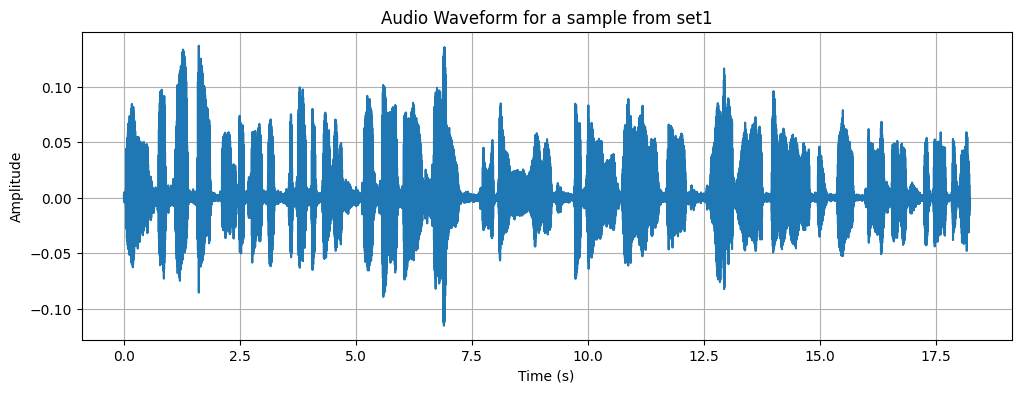


Playing audio:


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio


set1_fresh = hindi_valid.take(num_rows_per_set) # This will create a fresh iterable

# Get the first sample from the fresh set1
first_sample = next(iter(set1_fresh))

# Extract the audio data (waveform array and sampling rate) from the 'audio_filepath' feature
audio_data_decoded = first_sample['audio_filepath'] # This will be {'array': numpy_array, 'sampling_rate': int}
waveform = audio_data_decoded['array']
sampling_rate = audio_data_decoded['sampling_rate']

print(f"Sampling Rate: {sampling_rate} Hz")
print(f"Waveform shape: {waveform.shape}")
print(f"First 10 samples of waveform: {waveform[:10]}")

# Plot the waveform
plt.figure(figsize=(12, 4))
plt.plot(np.arange(len(waveform)) / sampling_rate, waveform)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Audio Waveform for a sample from set1")
plt.grid(True)
plt.show()

# Play the audio
print("\nPlaying audio:")
Audio(waveform, rate=sampling_rate)

**Preprocess Audio**

In [ ]:
# Corrected load_audio2 function definition
def load_audio2(audio_source, target_sr=16000):
    if isinstance(audio_source, tuple) and len(audio_source) == 2:
        # If input is (array, sr) from the dataset
        waveform_np, original_sr = audio_source
        # Convert numpy array to tensor, add channel dimension (batch_size, channels, samples)
        # Assuming mono audio in the numpy array, add a channel dimension
        waveform = torch.from_numpy(waveform_np).float().unsqueeze(0)
    else:
        # If input is a file path or other supported torchaudio.load type
        waveform, original_sr = torchaudio.load(audio_source)

    # Convert to mono by averaging channels (if not already mono)
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)

    # Resample if necessary
    if original_sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=original_sr, new_freq=target_sr)
        waveform = resampler(waveform)
    return waveform

**Running Inference**

In [ ]:
import json
from jiwer import process_words # Only import process_words
from tqdm import tqdm
import torch
import torchaudio
import numpy as np


references = []
predictions_ctc = []
predictions_rnnt=[]

print("Starting inference and metric collection for set1...")
# Ensure set1 is a fresh iterable, as it might have been consumed by previous operations
# Assuming `hindi_valid` and `num_rows_per_set` are available.
# If set1 was already consumed, this reinitializes it for this cell's loop.
current_set1_iterable = hindi_valid.take(num_rows_per_set)

for sample in tqdm(current_set1_iterable):

    # Extract audio data and reference text from the dataset sample
    # Corrected key from "audio" to "audio_filepath"
    audio_data_decoded = sample["audio_filepath"]
    reference_text = sample["text"]

    # Preprocess audio using the updated load_audio function
    language_code="hi"
    audio_input = load_audio2((audio_data_decoded['array'], audio_data_decoded['sampling_rate'])).to(device)

    # Transcribe audio
    # Using torch.no_grad() for inference to save memory and computations
    with torch.no_grad():
        transcription_ctc = model(audio_input, language_code, "ctc")
        transcription_rnnt = model(audio_input, language_code, "rnnt")

    predicted_text_ctc = transcription_ctc.strip()
    predicted_text_rnnt = transcription_rnnt.strip()

    references.append(reference_text)
    predictions_ctc.append(predicted_text_ctc)
    predictions_rnnt.append(predicted_text_rnnt)

print("Inference complete. Calculating metrics...")


In [ ]:
predictions_ctc[0]

'नमस्ते क्या आप सत्यापित कर सकते हैं कि जो जीन्स मैं चाहता हूँ वह पेटीएम मॉल पर भूरा रंग और नाप नाप चालीस में उपलब्ध है'

**Cacluating WER**

In [ ]:
from jiwer import process_words

# For CTC
total_substitutions_ctc = 0
total_deletions_ctc = 0
total_insertions_ctc = 0
total_reference_words_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics = process_words([ref], [pred])
    total_substitutions_ctc += metrics.substitutions
    total_deletions_ctc += metrics.deletions
    total_insertions_ctc += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_ctc += len(ref.split())

# For RNNT
total_substitutions_rnnt = 0
total_deletions_rnnt = 0
total_insertions_rnnt = 0
total_reference_words_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics = process_words([ref], [pred])
    total_substitutions_rnnt += metrics.substitutions
    total_deletions_rnnt += metrics.deletions
    total_insertions_rnnt += metrics.insertions
    # Calculate reference words for individual sentences
    total_reference_words_rnnt += len(ref.split())


print("\n--- CTC Model Results ---")
print(f"Total reference words: {total_reference_words_ctc}")
print(f"Total substitutions: {total_substitutions_ctc}")
print(f"Total deletions: {total_deletions_ctc}")
print(f"Total insertions: {total_insertions_ctc}")

print("\n--- RNNT Model Results ---")
print(f"Total reference words: {total_reference_words_rnnt}")
print(f"Total substitutions: {total_substitutions_rnnt}")
print(f"Total deletions: {total_deletions_rnnt}")
print(f"Total insertions: {total_insertions_rnnt}")


--- CTC Model Results ---
Total reference words: 16651
Total substitutions: 2025
Total deletions: 350
Total insertions: 262

--- RNNT Model Results ---
Total reference words: 16651
Total substitutions: 1769
Total deletions: 362
Total insertions: 265


**Calculating CER**

In [ ]:
from jiwer import process_characters, cer

# For CTC (Character-level)
total_substitutions_ctc_char = 0
total_deletions_ctc_char = 0
total_insertions_ctc_char = 0
total_reference_chars_ctc = 0

for ref, pred in zip(references, predictions_ctc):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_ctc_char += metrics_char.substitutions
    total_deletions_ctc_char += metrics_char.deletions
    total_insertions_ctc_char += metrics_char.insertions
    total_reference_chars_ctc += len(ref)

# For RNNT (Character-level)
total_substitutions_rnnt_char = 0
total_deletions_rnnt_char = 0
total_insertions_rnnt_char = 0
total_reference_chars_rnnt = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_rnnt_char += metrics_char.substitutions
    total_deletions_rnnt_char += metrics_char.deletions
    total_insertions_rnnt_char += metrics_char.insertions
    total_reference_chars_rnnt += len(ref)

# Calculate CER for both models
dataset_cer_ctc = cer(references, predictions_ctc)
dataset_cer_rnnt = cer(references, predictions_rnnt)

print("\n--- CTC Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_ctc}")
print(f"Total character substitutions: {total_substitutions_ctc_char}")
print(f"Total character deletions: {total_deletions_ctc_char}")
print(f"Total character insertions: {total_insertions_ctc_char}")
print(f"CER_ctc: {dataset_cer_ctc:.4f}")

print("\n--- RNNT Model Character-level Results ---")
print(f"Total reference characters: {total_reference_chars_rnnt}")
print(f"Total character substitutions: {total_substitutions_rnnt_char}")
print(f"Total character deletions: {total_deletions_rnnt_char}")
print(f"Total character insertions: {total_insertions_rnnt_char}")
print(f"CER_rnnt: {dataset_cer_rnnt:.4f}")


--- CTC Model Character-level Results ---
Total reference characters: 73417
Total character substitutions: 1623
Total character deletions: 2289
Total character insertions: 1268
CER_ctc: 0.0706

--- RNNT Model Character-level Results ---
Total reference characters: 73417
Total character substitutions: 1683
Total character deletions: 2217
Total character insertions: 1182
CER_rnnt: 0.0692


# **Working on Set 2**

**Running Inference**

In [ ]:
import json
from jiwer import process_words # Only import process_words
from tqdm import tqdm
import torch
import torchaudio
import numpy as np

references = []
predictions_ctc = []
predictions_rnnt=[]

print("Starting inference and metric collection for set2...")
# Re-initialize set2 to ensure it's not consumed and contains the correct samples
current_set2_iterable = hindi_valid.skip(num_rows_per_set).take(num_rows_per_set)

for sample in tqdm(current_set2_iterable):
    audio_data_decoded = sample["audio_filepath"]
    reference_text = sample["text"]

    language_code="hi"
    audio_input = load_audio2((audio_data_decoded['array'], audio_data_decoded['sampling_rate'])).to(device)

    with torch.no_grad():
        transcription_ctc = model(audio_input, language_code, "ctc")
        transcription_rnnt = model(audio_input, language_code, "rnnt")

    predicted_text_ctc = transcription_ctc.strip()
    predicted_text_rnnt = transcription_rnnt.strip()

    references.append(reference_text)
    predictions_ctc.append(predicted_text_ctc)
    predictions_rnnt.append(predicted_text_rnnt)

print("Inference for set2 complete. Calculating metrics...")

**Calculating WER for Set2**

In [ ]:
from jiwer import process_words

# For CTC (Set2)
total_substitutions_ctc_set2 = 0
total_deletions_ctc_set2 = 0
total_insertions_ctc_set2 = 0
total_reference_words_ctc_set2 = 0

for ref, pred in zip(references, predictions_ctc):
    metrics = process_words([ref], [pred])
    total_substitutions_ctc_set2 += metrics.substitutions
    total_deletions_ctc_set2 += metrics.deletions
    total_insertions_ctc_set2 += metrics.insertions
    total_reference_words_ctc_set2 += len(ref.split())

# For RNNT (Set2)
total_substitutions_rnnt_set2 = 0
total_deletions_rnnt_set2 = 0
total_insertions_rnnt_set2 = 0
total_reference_words_rnnt_set2 = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics = process_words([ref], [pred])
    total_substitutions_rnnt_set2 += metrics.substitutions
    total_deletions_rnnt_set2 += metrics.deletions
    total_insertions_rnnt_set2 += metrics.insertions
    total_reference_words_rnnt_set2 += len(ref.split())


print("\n--- CTC Model Results (Set2) ---")
print(f"Total reference words: {total_reference_words_ctc_set2}")
print(f"Total substitutions: {total_substitutions_ctc_set2}")
print(f"Total deletions: {total_deletions_ctc_set2}")
print(f"Total insertions: {total_insertions_ctc_set2}")

print("\n--- RNNT Model Results (Set2) ---")
print(f"Total reference words: {total_reference_words_rnnt_set2}")
print(f"Total substitutions: {total_substitutions_rnnt_set2}")
print(f"Total deletions: {total_deletions_rnnt_set2}")
print(f"Total insertions: {total_insertions_rnnt_set2}")


--- CTC Model Results (Set2) ---
Total reference words: 20467
Total substitutions: 2634
Total deletions: 498
Total insertions: 317

--- RNNT Model Results (Set2) ---
Total reference words: 20467
Total substitutions: 2358
Total deletions: 539
Total insertions: 305


**Calculating CER for Set2**

In [ ]:
from jiwer import process_characters, cer

# For CTC (Character-level, Set2)
total_substitutions_ctc_char_set2 = 0
total_deletions_ctc_char_set2 = 0
total_insertions_ctc_char_set2 = 0
total_reference_chars_ctc_set2 = 0

for ref, pred in zip(references, predictions_ctc):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_ctc_char_set2 += metrics_char.substitutions
    total_deletions_ctc_char_set2 += metrics_char.deletions
    total_insertions_ctc_char_set2 += metrics_char.insertions
    total_reference_chars_ctc_set2 += len(ref)

# For RNNT (Character-level, Set2)
total_substitutions_rnnt_char_set2 = 0
total_deletions_rnnt_char_set2 = 0
total_insertions_rnnt_char_set2 = 0
total_reference_chars_rnnt_set2 = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_rnnt_char_set2 += metrics_char.substitutions
    total_deletions_rnnt_char_set2 += metrics_char.deletions
    total_insertions_rnnt_char_set2 += metrics_char.insertions
    total_reference_chars_rnnt_set2 += len(ref)

# Calculate CER for both models (Set2)
dataset_cer_ctc_set2 = cer(references, predictions_ctc)
dataset_cer_rnnt_set2 = cer(references, predictions_rnnt)

print("\n--- CTC Model Character-level Results (Set2) ---")
print(f"Total reference characters: {total_reference_chars_ctc_set2}")
print(f"Total character substitutions: {total_substitutions_ctc_char_set2}")
print(f"Total character deletions: {total_deletions_ctc_char_set2}")
print(f"Total character insertions: {total_insertions_ctc_char_set2}")
print(f"CER_ctc: {dataset_cer_ctc_set2:.4f}")

print("\n--- RNNT Model Character-level Results (Set2) ---")
print(f"Total reference characters: {total_reference_chars_rnnt_set2}")
print(f"Total character substitutions: {total_substitutions_rnnt_char_set2}")
print(f"Total character deletions: {total_deletions_rnnt_char_set2}")
print(f"Total character insertions: {total_insertions_rnnt_char_set2}")
print(f"CER_rnnt: {dataset_cer_rnnt_set2:.4f}")


--- CTC Model Character-level Results (Set2) ---
Total reference characters: 91634
Total character substitutions: 2228
Total character deletions: 3074
Total character insertions: 1517
CER_ctc: 0.0744

--- RNNT Model Character-level Results (Set2) ---
Total reference characters: 91634
Total character substitutions: 2356
Total character deletions: 2969
Total character insertions: 1364
CER_rnnt: 0.0730


# Working on Set 3

**Running Inference**

In [ ]:
import json
from jiwer import process_words # Only import process_words
from tqdm import tqdm
import torch
import torchaudio
import numpy as np

references = []
predictions_ctc = []
predictions_rnnt=[]

print("Starting inference and metric collection for set3...")
# Re-initialize set3 to ensure it's not consumed and contains the correct samples
current_set3_iterable = hindi_valid.skip(2 * num_rows_per_set).take(num_rows_per_set)

for sample_idx, sample in tqdm(enumerate(current_set3_iterable)):
    audio_data_decoded = sample["audio_filepath"]
    reference_text = sample["text"]

    language_code="hi"
    try:
        audio_input = load_audio2((audio_data_decoded['array'], audio_data_decoded['sampling_rate'])).to(device)

        with torch.no_grad():
            transcription_ctc = model(audio_input, language_code, "ctc")
            transcription_rnnt = model(audio_input, language_code, "rnnt")

        predicted_text_ctc = transcription_ctc.strip()
        predicted_text_rnnt = transcription_rnnt.strip()

        references.append(reference_text)
        predictions_ctc.append(predicted_text_ctc)
        predictions_rnnt.append(predicted_text_rnnt)
    except RuntimeError as e:
        print(f"Skipping sample {sample_idx} due to audio processing error: {e}. Sample details: {sample}")
        continue

print("Inference for set3 complete. Calculating metrics...")

**Calculating WER for Set3**

In [ ]:
from jiwer import process_words

# For CTC (Set3)
total_substitutions_ctc_set3 = 0
total_deletions_ctc_set3 = 0
total_insertions_ctc_set3 = 0
total_reference_words_ctc_set3 = 0

for ref, pred in zip(references, predictions_ctc):
    metrics = process_words([ref], [pred])
    total_substitutions_ctc_set3 += metrics.substitutions
    total_deletions_ctc_set3 += metrics.deletions
    total_insertions_ctc_set3 += metrics.insertions
    total_reference_words_ctc_set3 += len(ref.split())

# For RNNT (Set3)
total_substitutions_rnnt_set3 = 0
total_deletions_rnnt_set3 = 0
total_insertions_rnnt_set3 = 0
total_reference_words_rnnt_set3 = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics = process_words([ref], [pred])
    total_substitutions_rnnt_set3 += metrics.substitutions
    total_deletions_rnnt_set3 += metrics.deletions
    total_insertions_rnnt_set3 += metrics.insertions
    total_reference_words_rnnt_set3 += len(ref.split())


print("\n--- CTC Model Results (Set3) ---")
print(f"Total reference words: {total_reference_words_ctc_set3}")
print(f"Total substitutions: {total_substitutions_ctc_set3}")
print(f"Total deletions: {total_deletions_ctc_set3}")
print(f"Total insertions: {total_insertions_ctc_set3}")

print("\n--- RNNT Model Results (Set3) ---")
print(f"Total reference words: {total_reference_words_rnnt_set3}")
print(f"Total substitutions: {total_substitutions_rnnt_set3}")
print(f"Total deletions: {total_deletions_rnnt_set3}")
print(f"Total insertions: {total_insertions_rnnt_set3}")


--- CTC Model Results (Set3) ---
Total reference words: 17215
Total substitutions: 2345
Total deletions: 480
Total insertions: 376

--- RNNT Model Results (Set3) ---
Total reference words: 17215
Total substitutions: 2100
Total deletions: 498
Total insertions: 370


**Calculating CER for Set3**

In [ ]:
from jiwer import process_characters, cer

# For CTC (Character-level, Set3)
total_substitutions_ctc_char_set3 = 0
total_deletions_ctc_char_set3 = 0
total_insertions_ctc_char_set3 = 0
total_reference_chars_ctc_set3 = 0

for ref, pred in zip(references, predictions_ctc):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_ctc_char_set3 += metrics_char.substitutions
    total_deletions_ctc_char_set3 += metrics_char.deletions
    total_insertions_ctc_char_set3 += metrics_char.insertions
    total_reference_chars_ctc_set3 += len(ref)

# For RNNT (Character-level, Set3)
total_substitutions_rnnt_char_set3 = 0
total_deletions_rnnt_char_set3 = 0
total_insertions_rnnt_char_set3 = 0
total_reference_chars_rnnt_set3 = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_rnnt_char_set3 += metrics_char.substitutions
    total_deletions_rnnt_char_set3 += metrics_char.deletions
    total_insertions_rnnt_char_set3 += metrics_char.insertions
    total_reference_chars_rnnt_set3 += len(ref)

# Calculate CER for both models (Set3)
dataset_cer_ctc_set3 = cer(references, predictions_ctc)
dataset_cer_rnnt_set3 = cer(references, predictions_rnnt)

print("\n--- CTC Model Character-level Results (Set3) ---")
print(f"Total reference characters: {total_reference_chars_ctc_set3}")
print(f"Total character substitutions: {total_substitutions_ctc_char_set3}")
print(f"Total character deletions: {total_deletions_ctc_char_set3}")
print(f"Total character insertions: {total_insertions_ctc_char_set3}")
print(f"CER_ctc: {dataset_cer_ctc_set3:.4f}")

print("\n--- RNNT Model Character-level Results (Set3) ---")
print(f"Total reference characters: {total_reference_chars_rnnt_set3}")
print(f"Total character substitutions: {total_substitutions_rnnt_char_set3}")
print(f"Total character deletions: {total_deletions_rnnt_char_set3}")
print(f"Total character insertions: {total_insertions_rnnt_char_set3}")
print(f"CER_rnnt: {dataset_cer_rnnt_set3:.4f}")


--- CTC Model Character-level Results (Set3) ---
Total reference characters: 76748
Total character substitutions: 2132
Total character deletions: 3027
Total character insertions: 1431
CER_ctc: 0.0859

--- RNNT Model Character-level Results (Set3) ---
Total reference characters: 76748
Total character substitutions: 2268
Total character deletions: 2815
Total character insertions: 1397
CER_rnnt: 0.0844


# Working on Set4

**Running Inference**

In [ ]:
import json
from jiwer import process_words # Only import process_words
from tqdm import tqdm
import torch
import torchaudio
import numpy as np

references = []
predictions_ctc = []
predictions_rnnt=[]

print("Starting inference and metric collection for set4...")
# Re-initialize set4 to ensure it's not consumed and contains the correct samples
current_set4_iterable = hindi_valid.skip(3 * num_rows_per_set).take(num_rows_per_set)

for sample_idx, sample in tqdm(enumerate(current_set4_iterable)):
    audio_data_decoded = sample["audio_filepath"]
    reference_text = sample["text"]

    language_code="hi"
    try:
        audio_input = load_audio2((audio_data_decoded['array'], audio_data_decoded['sampling_rate'])).to(device)

        with torch.no_grad():
            transcription_ctc = model(audio_input, language_code, "ctc")
            transcription_rnnt = model(audio_input, language_code, "rnnt")

        predicted_text_ctc = transcription_ctc.strip()
        predicted_text_rnnt = transcription_rnnt.strip()

        references.append(reference_text)
        predictions_ctc.append(predicted_text_ctc)
        predictions_rnnt.append(predicted_text_rnnt)
    except RuntimeError as e:
        print(f"Skipping sample {sample_idx} due to audio processing error: {e}. Sample details: {sample}")
        continue

print("Inference for set4 complete. Calculating metrics...")

**Calculating WER for Set4**

In [ ]:
from jiwer import process_words

# For CTC (Set4)
total_substitutions_ctc_set4 = 0
total_deletions_ctc_set4 = 0
total_insertions_ctc_set4 = 0
total_reference_words_ctc_set4 = 0

for ref, pred in zip(references, predictions_ctc):
    metrics = process_words([ref], [pred])
    total_substitutions_ctc_set4 += metrics.substitutions
    total_deletions_ctc_set4 += metrics.deletions
    total_insertions_ctc_set4 += metrics.insertions
    total_reference_words_ctc_set4 += len(ref.split())

# For RNNT (Set4)
total_substitutions_rnnt_set4 = 0
total_deletions_rnnt_set4 = 0
total_insertions_rnnt_set4 = 0
total_reference_words_rnnt_set4 = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics = process_words([ref], [pred])
    total_substitutions_rnnt_set4 += metrics.substitutions
    total_deletions_rnnt_set4 += metrics.deletions
    total_insertions_rnnt_set4 += metrics.insertions
    total_reference_words_rnnt_set4 += len(ref.split())


print("\n--- CTC Model Results (Set4) ---")
print(f"Total reference words: {total_reference_words_ctc_set4}")
print(f"Total substitutions: {total_substitutions_ctc_set4}")
print(f"Total deletions: {total_deletions_ctc_set4}")
print(f"Total insertions: {total_insertions_ctc_set4}")

print("\n--- RNNT Model Results (Set4) ---")
print(f"Total reference words: {total_reference_words_rnnt_set4}")
print(f"Total substitutions: {total_substitutions_rnnt_set4}")
print(f"Total deletions: {total_deletions_rnnt_set4}")
print(f"Total insertions: {total_insertions_rnnt_set4}")


--- CTC Model Results (Set4) ---
Total reference words: 19009
Total substitutions: 2180
Total deletions: 403
Total insertions: 303

--- RNNT Model Results (Set4) ---
Total reference words: 19009
Total substitutions: 1945
Total deletions: 404
Total insertions: 307


**Calculating CER for Set4**

In [ ]:
from jiwer import process_characters, cer

# For CTC (Character-level, Set4)
total_substitutions_ctc_char_set4 = 0
total_deletions_ctc_char_set4 = 0
total_insertions_ctc_char_set4 = 0
total_reference_chars_ctc_set4 = 0

for ref, pred in zip(references, predictions_ctc):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_ctc_char_set4 += metrics_char.substitutions
    total_deletions_ctc_char_set4 += metrics_char.deletions
    total_insertions_ctc_char_set4 += metrics_char.insertions
    total_reference_chars_ctc_set4 += len(ref)

# For RNNT (Character-level, Set4)
total_substitutions_rnnt_char_set4 = 0
total_deletions_rnnt_char_set4 = 0
total_insertions_rnnt_char_set4 = 0
total_reference_chars_rnnt_set4 = 0

for ref, pred in zip(references, predictions_rnnt):
    metrics_char = process_characters([ref], [pred])
    total_substitutions_rnnt_char_set4 += metrics_char.substitutions
    total_deletions_rnnt_char_set4 += metrics_char.deletions
    total_insertions_rnnt_char_set4 += metrics_char.insertions
    total_reference_chars_rnnt_set4 += len(ref)

# Calculate CER for both models (Set4)
dataset_cer_ctc_set4 = cer(references, predictions_ctc)
dataset_cer_rnnt_set4 = cer(references, predictions_rnnt)

print("\n--- CTC Model Character-level Results (Set4) ---")
print(f"Total reference characters: {total_reference_chars_ctc_set4}")
print(f"Total character substitutions: {total_substitutions_ctc_char_set4}")
print(f"Total character deletions: {total_deletions_ctc_char_set4}")
print(f"Total character insertions: {total_insertions_ctc_char_set4}")
print(f"CER_ctc: {dataset_cer_ctc_set4:.4f}")

print("\n--- RNNT Model Character-level Results (Set4) ---")
print(f"Total reference characters: {total_reference_chars_rnnt_set4}")
print(f"Total character substitutions: {total_substitutions_rnnt_char_set4}")
print(f"Total character deletions: {total_deletions_rnnt_char_set4}")
print(f"Total character insertions: {total_insertions_rnnt_char_set4}")
print(f"CER_rnnt: {dataset_cer_rnnt_set4:.4f}")


--- CTC Model Character-level Results (Set4) ---
Total reference characters: 84785
Total character substitutions: 1838
Total character deletions: 2302
Total character insertions: 1406
CER_ctc: 0.0654

--- RNNT Model Character-level Results (Set4) ---
Total reference characters: 84785
Total character substitutions: 1918
Total character deletions: 2189
Total character insertions: 1282
CER_rnnt: 0.0636
